In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from skimage.measure import regionprops_table
import tifffile
from pathlib import Path
from tqdm import tqdm

In [56]:
BASE_PATH = Path(r"D:\Charlotte\CC_E19\Overall Segmentation")
subdirectories = [d for d in BASE_PATH.glob("*") if d.is_dir()]

all_all_dfs = {}

for subdir in subdirectories[9:11]:
    raw_tif_file = list(subdir.glob("*.tif"))[0]
    cell_line = raw_tif_file.stem.split(" ")[1]
    print(cell_line)

    raw_data = tifffile.imread(raw_tif_file)

    cell_masks_file = list((subdir / "Full Cells" / "masks").glob("*.tif"))[0]
    cell_masks = tifffile.imread(cell_masks_file)

    nuclei_masks_file = list((subdir / "Nuclei" / "masks").glob("*.tif"))[0]
    nuclei_masks = tifffile.imread(nuclei_masks_file)

    all_dfs = []

    for frame in tqdm(range(nuclei_masks.shape[0])):
        cell_frame = cell_masks[frame]
        nuclei_frame = nuclei_masks[frame]
        raw_frame = raw_data[frame]

        df = regionprops_table(nuclei_frame, cell_frame, properties=('label', 'intensity_median'))

        mapping = {label: int(cell_label) for label, cell_label in zip(df["label"], df["intensity_median"]) if cell_label > 0}

        df_nuclei = regionprops_table(nuclei_frame, raw_frame, properties = (
            "label", "area", "intensity_mean", "centroid"
        ))

        df_nuclei = pd.DataFrame(df_nuclei, index=df_nuclei["label"])

        df_nuclei.rename(
            columns = {
                "area": "nuclei_area_px",
                "intensity_mean-0": "nuclei_red",
                "intensity_mean-1": "nuclei_green",
                "intensity_mean-2": "nuclei_blue",
                "centroid-0": "y_px",
                "centroid-1": "x_px",
            },

            inplace=True
        )

        df_nuclei["cell_label"] = df_nuclei["label"].map(mapping).fillna(0).astype(int)
        # print(df_nuclei)

        df_cell = regionprops_table(cell_frame, raw_frame, properties = (
            "label", "area", "intensity_mean"
        ))

        df_cell = pd.DataFrame(df_cell, index=df_cell["label"])

        df_nuclei["cell_area_px"] = df_nuclei["cell_label"].map(df_cell["area"])
        df_nuclei["cell_red"] = df_nuclei["cell_label"].map(df_cell["intensity_mean-0"])
        df_nuclei["cell_green"] = df_nuclei["cell_label"].map(df_cell["intensity_mean-1"])
        df_nuclei["cell_blue"] = df_nuclei["cell_label"].map(df_cell["intensity_mean-2"])

        df_nuclei["frame"] = frame

        all_dfs.append(df_nuclei)

    all_cells = pd.concat(all_dfs, ignore_index=True)
    all_all_dfs[raw_tif_file.stem] = all_cells







pPF058


100%|██████████| 145/145 [00:34<00:00,  4.24it/s]


pPF058


100%|██████████| 145/145 [00:37<00:00,  3.82it/s]


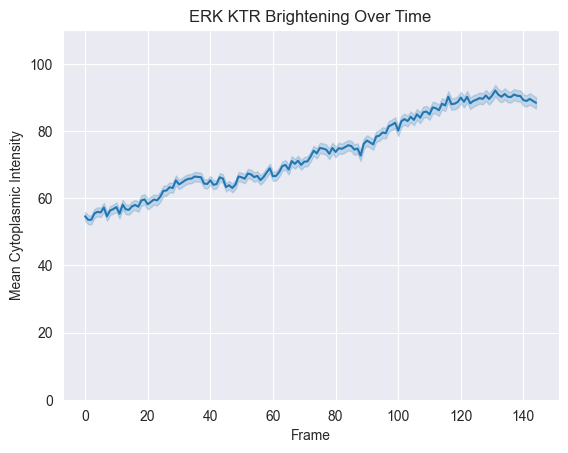

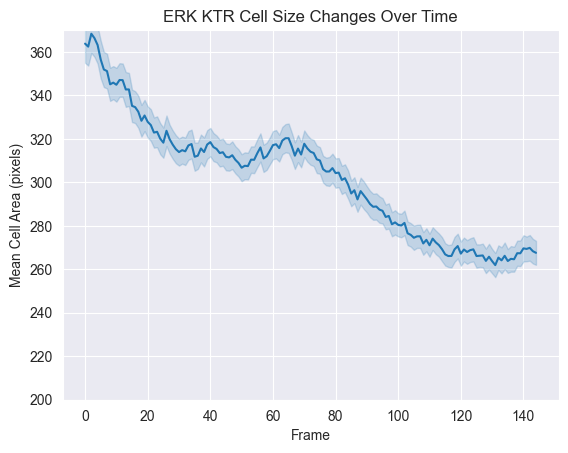

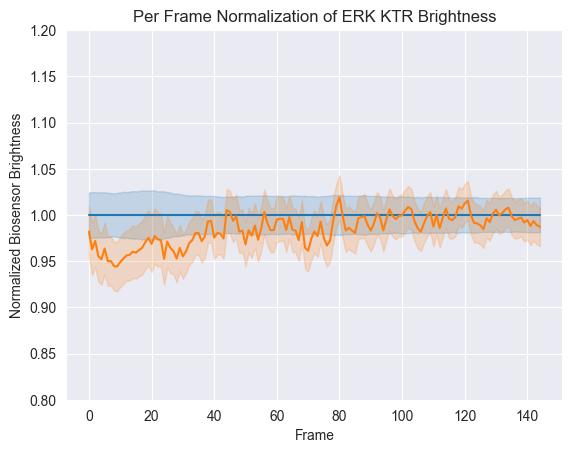

In [57]:
sns.lineplot(all_cells, x="frame", y="cell_green", errorbar=("se", 2))
plt.ylim(0,110)
plt.xlabel("Frame")
plt.ylabel("Mean Cytoplasmic Intensity")
plt.title("ERK KTR Brightening Over Time")
plt.show()
sns.lineplot(all_cells, x="frame", y="cell_area_px", errorbar=("se", 2))
plt.ylim(200,370)
plt.xlabel("Frame")
plt.ylabel("Mean Cell Area (pixels)")
plt.title("ERK KTR Cell Size Changes Over Time")
plt.show()

all_cells["cell_green_normalized"] = all_cells["cell_green"] / all_cells["frame"].map(all_cells.groupby("frame")["cell_green"].mean())
all_cells["nuclei_green_normalized"] = all_cells["nuclei_green"] / all_cells["frame"].map(all_cells.groupby("frame")["cell_green"].mean())


sns.lineplot(all_cells, x="frame", y="cell_green_normalized", errorbar=("se", 2))
sns.lineplot(all_cells, x="frame", y="nuclei_green_normalized", errorbar=("se", 2))
plt.ylim(0.8,1.2)
plt.xlabel("Frame")
plt.ylabel("Normalized Biosensor Brightness")
plt.title("Per Frame Normalization of ERK KTR Brightness")
plt.show()

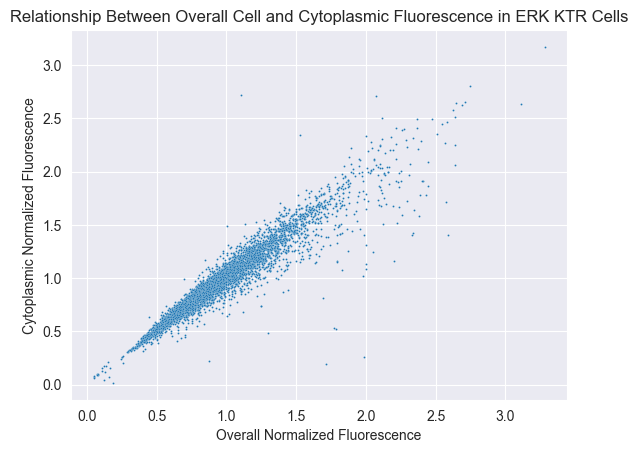

In [58]:
all_cells["cyto_green"] = ( (all_cells["cell_green"] * all_cells["cell_area_px"]) -
                            (all_cells["nuclei_green"] * all_cells["nuclei_area_px"]) ) / (all_cells["cell_area_px"] - all_cells["nuclei_area_px"])

all_cells["cyto_green_normalized"] = ( (all_cells["cell_green_normalized"] * all_cells["cell_area_px"]) -
                            (all_cells["nuclei_green_normalized"] * all_cells["nuclei_area_px"]) ) / (all_cells["cell_area_px"] - all_cells["nuclei_area_px"])

sns.scatterplot(all_cells.sample(5000), x="cell_green_normalized", y="cyto_green_normalized", s=2)
plt.xlabel("Overall Normalized Fluorescence")
plt.ylabel("Cytoplasmic Normalized Fluorescence")
plt.title("Relationship Between Overall Cell and Cytoplasmic Fluorescence in ERK KTR Cells")
plt.show()

175.0


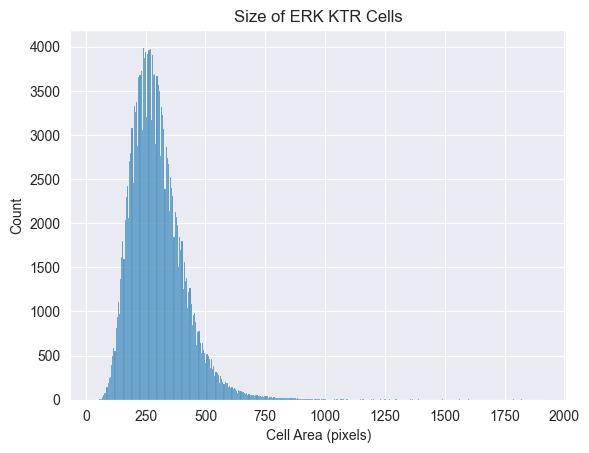

In [60]:
sns.histplot(all_cells, x="cell_area_px")
print(all_cells["cell_area_px"].quantile(0.10))
plt.xlabel("Cell Area (pixels)")
plt.title("Size of ERK KTR Cells")
plt.show()


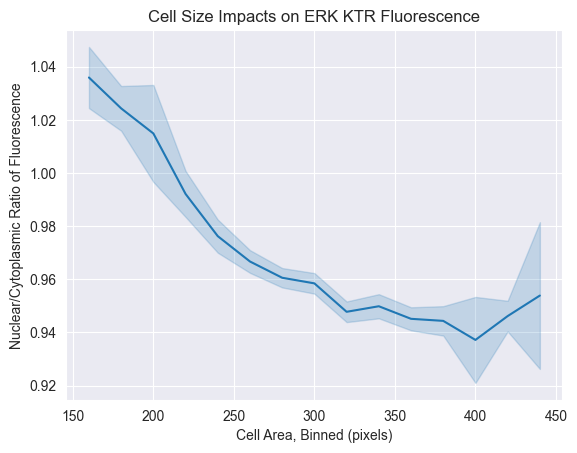

In [61]:
all_cells["nc_ratio_green"] = all_cells["nuclei_green"] / all_cells["cyto_green"]
all_cells["nc_ratio_green_normalized"] = all_cells["nuclei_green_normalized"] / all_cells["cyto_green_normalized"]


all_cells["area_bin"] = all_cells["cell_area_px"] // 20 * 20

#from the 10th to the 90th percentile in cell size
sns.lineplot(all_cells.query("cell_area_px.between(175, 440)"), x="area_bin", y="nc_ratio_green_normalized", errorbar=("se", 2))
#sns.lineplot(all_cells.query("cell_area_px.between(180, 427)"), x="area_bin", y="nuclei_green", errorbar=("se", 2))
plt.xlabel("Cell Area, Binned (pixels)")
plt.ylabel("Nuclear/Cytoplasmic Ratio of Fluorescence")
plt.title("Cell Size Impacts on ERK KTR Fluorescence")
plt.show()

<Axes: xlabel='frame', ylabel='nc_ratio_green_normalized'>

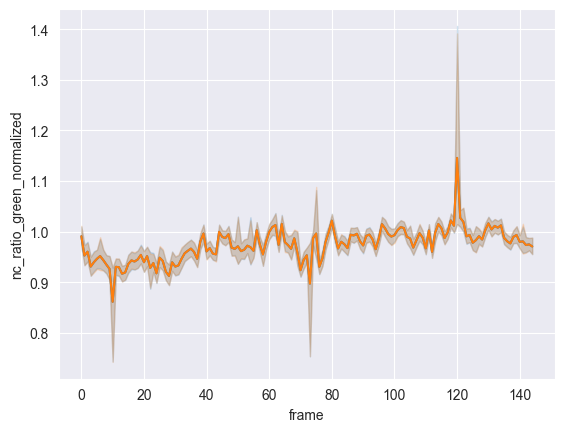

In [71]:
sns.lineplot(all_cells.query("cell_area_px.between(180, 360)"), x="frame", y="nc_ratio_green_normalized")
sns.lineplot(all_cells.query("cell_area_px.between(180, 360)"), x="frame", y="nc_ratio_green")